# 02 · Reaction to purification

**Goal.** Continue a reaction through phase setup, extraction, wash, drying and concentration while keeping validation, transaction and measurement receipts visible.

> 中文提示：重点是“操作—观测—资源”的完整记录，不是寻找最高分 recipe。


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "chemworld-bench[notebooks] @ git+https://github.com/sunyrain/ChemWorld-Public.git@v0.3.0",
    ])

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import chemworld

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (9, 3.8), "figure.dpi": 110})
print(f"ChemWorld {chemworld.__version__} · provider-free deterministic tutorial")


ChemWorld 0.3.0 · provider-free deterministic tutorial


## 1. Inspect purification affordances


In [2]:
env = gym.make("ChemWorld", task_id="reaction-to-purification", seed=0)
_observation, _info = env.reset(seed=0)
prompt = env.unwrapped.task_prompt()
display(pd.DataFrame({
    "field": ["task_id", "objective", "episode_mode", "success_metrics", "allowed_instruments"],
    "public value": [prompt["task_id"], prompt["objective"], prompt["episode_mode"], prompt["success_metrics"], prompt["allowed_instruments"]],
}))
for operation in ("add_extractant", "separate_phase", "wash", "concentrate"):
    schema = env.unwrapped.action_schema(operation)
    print(operation, "→", schema["required_fields"])
env.close()


,field,public value
0,task_id,reaction-to-purification
1,objective,balanced
2,episode_mode,single_experiment
3,success_metrics,"[score, purity, recovery, process_mass_balance..."
4,allowed_instruments,"[final_assay, gc, hplc, uvvis]"


add_extractant → ['extractant', 'volume_L']
separate_phase → ['target_phase']
wash → ['wash_volume_L']
concentrate → ['duration_s']


## 2. Define the reaction-to-purification recipe


In [3]:
recipe = [
    {"operation": "add_solvent", "volume_L": 0.030, "solvent": 1},
    {"operation": "add_reagent", "amount_mol": 0.012},
    {"operation": "add_catalyst", "catalyst": 2, "catalyst_amount_mol": 0.0004},
    {"operation": "heat", "target_temperature_K": 350.0, "duration_s": 1200.0, "stirring_speed_rpm": 800.0},
    {"operation": "quench"},
    {"operation": "add_phase", "phase": "organic", "volume_L": 0.020},
    {"operation": "add_extractant", "extractant": "organic", "volume_L": 0.010},
    {"operation": "mix", "duration_s": 120.0, "stirring_speed_rpm": 600.0},
    {"operation": "settle", "duration_s": 300.0},
    {"operation": "separate_phase", "target_phase": "organic"},
    {"operation": "wash", "wash_volume_L": 0.010},
    {"operation": "dry"},
    {"operation": "concentrate", "duration_s": 300.0},
    {"operation": "terminate"},
    {"operation": "measure", "instrument": "final_assay"},
]
display(pd.DataFrame([
    {"step": step, "operation": action["operation"], "public payload": {k: v for k, v in action.items() if k != "operation"}}
    for step, action in enumerate(recipe, start=1)
]))


,step,operation,public payload
0,1,add_solvent,"{'volume_L': 0.03, 'solvent': 1}"
1,2,add_reagent,{'amount_mol': 0.012}
2,3,add_catalyst,"{'catalyst': 2, 'catalyst_amount_mol': 0.0004}"
3,4,heat,"{'target_temperature_K': 350.0, 'duration_s': ..."
4,5,quench,{}
5,6,add_phase,"{'phase': 'organic', 'volume_L': 0.02}"
6,7,add_extractant,"{'extractant': 'organic', 'volume_L': 0.01}"
7,8,mix,"{'duration_s': 120.0, 'stirring_speed_rpm': 60..."
8,9,settle,{'duration_s': 300.0}
9,10,separate_phase,{'target_phase': 'organic'}


In [4]:
def run_recipe(task_id: str, recipe: list[dict], *, seed: int = 0) -> tuple[pd.DataFrame, dict]:
    """Execute typed actions while retaining public validation and resource fields."""
    env = gym.make("ChemWorld", task_id=task_id, seed=seed)
    _observation, info = env.reset(seed=seed)
    rows = []
    final_info = info
    try:
        for step, action in enumerate(recipe, start=1):
            validation = env.unwrapped.validate_action(action)
            _observation, reward, terminated, truncated, info = env.step(action)
            final_info = dict(info)
            rows.append({
                "step": step,
                "operation": action["operation"],
                "valid": bool(validation["valid"]),
                "transaction": info.get("transaction_status"),
                "reward": float(reward),
                "leaderboard_score": info.get("leaderboard_score"),
                "cost_total": info.get("cost"),
                "cost_delta": info.get("cost_delta"),
                "sample_delta_L": info.get("sample_delta"),
                "risk_delta": info.get("risk_delta"),
                "observed_keys": ", ".join(info.get("observed_keys", ())),
                "terminated": bool(terminated),
                "truncated": bool(truncated),
            })
            if terminated or truncated:
                break
    finally:
        env.close()
    frame = pd.DataFrame(rows)
    assert frame["valid"].all(), "Every tutorial request must validate before execution."
    assert frame["transaction"].eq("committed").all(), "Every tutorial action must commit."
    return frame, final_info


## 3. Execute the complete lifecycle


In [5]:
trace, final_info = run_recipe("reaction-to-purification", recipe, seed=0)
display(trace)
assert final_info.get("instrument") == "final_assay"
assert not trace["truncated"].any()


,step,operation,valid,transaction,reward,leaderboard_score,cost_total,cost_delta,sample_delta_L,risk_delta,observed_keys,terminated,truncated
0,1,add_solvent,True,committed,0.0000,NaN,0.0,0.0192,0.0000,5.9794e-02,"cost, safety_risk, score",False,False
1,2,add_reagent,True,committed,0.0000,NaN,0.0,0.0360,0.0000,2.3018e-02,"cost, safety_risk, score",False,False
2,3,add_catalyst,True,committed,0.0000,NaN,0.0,0.1920,0.0000,0.0000e+00,"cost, safety_risk, score",False,False
3,4,heat,True,committed,0.0000,NaN,0.0,0.0100,0.0000,7.9788e-03,"cost, safety_risk, score",False,False
4,5,quench,True,committed,0.0000,NaN,0.0,0.0517,0.0000,-6.6220e-03,"cost, safety_risk, score",False,False
5,6,add_phase,True,committed,0.0000,NaN,0.0,0.0220,0.0000,-1.3472e-02,"cost, safety_risk, score",False,False
6,7,add_extractant,True,committed,0.0000,NaN,0.0,0.0330,0.0000,-2.2921e-03,"cost, safety_risk, score",False,False
7,8,mix,True,committed,0.0000,NaN,0.0,0.0105,0.0000,0.0000e+00,"cost, safety_risk, score",False,False
8,9,settle,True,committed,0.0000,NaN,0.0,0.0005,0.0000,0.0000e+00,"cost, safety_risk, score",False,False
9,10,separate_phase,True,committed,0.0000,NaN,0.0,0.0250,0.0000,-7.0632e-03,"cost, safety_risk, score",False,False


## 4. Read the purity–recovery–cost trade-off


,purity,recovery,yield,mass-balance error,safety risk,total cost,leaderboard score
0,0.6289,0.0209,0.0086,0.0,None,0.0,0.2253


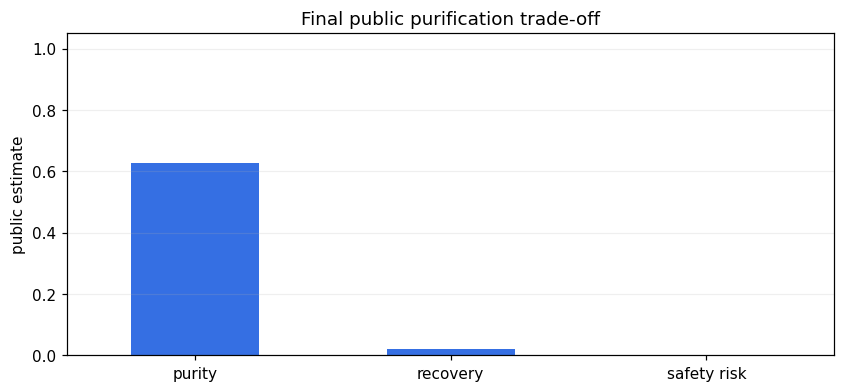

In [6]:
metrics = final_info.get("processed_estimate", {})
tradeoff = pd.DataFrame([{
    "purity": metrics.get("purity"),
    "recovery": metrics.get("recovery"),
    "yield": metrics.get("yield"),
    "mass-balance error": metrics.get("process_mass_balance_error"),
    "safety risk": metrics.get("safety_risk"),
    "total cost": final_info.get("cost"),
    "leaderboard score": final_info.get("leaderboard_score"),
}])
display(tradeoff)

visible = tradeoff[["purity", "recovery", "safety risk"]].T.rename(columns={0: "public estimate"})
ax = visible.plot(kind="bar", color="#356fe3", legend=False)
ax.set(title="Final public purification trade-off", ylim=(0, 1.05), ylabel="public estimate")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=0)
plt.show()


## 5. Choose one controlled follow-up


In [7]:
follow_up = {
    "question": "Does a larger organic phase improve recovery without losing purity?",
    "change_one_control": {"add_phase_volume_L": 0.030},
    "hold_fixed": ["reaction conditions", "extractant identity", "mix/settle times", "target phase", "seed"],
    "readouts": ["purity", "recovery", "process_mass_balance_error", "cost"],
}
follow_up


{'question': 'Does a larger organic phase improve recovery without losing purity?',
 'change_one_control': {'add_phase_volume_L': 0.03},
 'hold_fixed': ['reaction conditions',
  'extractant identity',
  'mix/settle times',
  'target phase',
  'seed'],
 'readouts': ['purity', 'recovery', 'process_mass_balance_error', 'cost']}